In [24]:
import numpy as np
import pandas as pd
import plotly.express as px

from numpy.random import seed
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import statsmodels.api as sm

By the end of this activity, students should be able to

1. Implement gradient descent from scratch for the logistic regression.

2. Explain pitfalls of the gradient descent algorithm.


## Mode

Please run the Python chunks one by one, look at the output and make sure that you understand how it is produced. There will be questions that either require a short answer - then you type your answer right in this document - or writing Python codes - then you write Python codes here. In either case, you can discuss your work with your teammates and with Fedor.

## Data

Here we download the data on the Titanic survivors from the following URL:

https://campus.datacamp.com/courses/kaggle-python-tutorial-on-machine-learning/getting-started-with-python?ex=2

In [25]:
# Load the train and test datasets to create two DataFrames
url = "http://s3.amazonaws.com/assets.datacamp.com/course/Kaggle/train.csv"
T = pd.read_csv(url)
T.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Here is an overview of the data:

In [26]:
T.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


We will use a passenger's age as one of predictors. To avoid problems with missing values (and the objective of this handout is to understand gradient descent, not missing values imputation), we will just remove observations with missing age.

In [27]:
print("The number of observations with missing age is", np.sum(T['Age'].isna()))
T = T.loc[~T['Age'].isna()]
print("Now dim(data) =", T.shape)

The number of observations with missing age is 177
Now dim(data) = (714, 12)


# Data exploration

Here is a simple scatterplot of the data on the axes (log(Fare), Age)

In [28]:
px.scatter(T, x = 'Fare', y = 'Age', color = 'Survived', log_x=True)

### Exercise 1

Based on the plot, how do you think age and ticket price are related to survival on Titanic? Were older people more likely to survive than younger people? Were people with expensive tickets more likely to survive than people with cheap tickets?

__YOUR ANSWER:__<br>
Higher fare, Higher possibility of survival


__END OF EXERCISE 1__

# Training and test sets

We will now create our training and test sets. We will split the data into 70% training and 30% test sets.

In [29]:
all_x = np.array(T[['Age', 'Fare']])
all_y = np.array(T[['Survived']])

x_train, x_test, y_train, y_test = train_test_split(all_x, all_y, test_size=0.3, random_state = 8128)
print("X dimensions =", all_x.shape)
print("Y dimensions =", all_y.shape)
print("Train X dimensions =", x_train.shape)
print("Train Y dimensions =", y_train.shape)
print("Test X dimensions =", x_test.shape)
print("Test Y dimensions =", y_test.shape)

X dimensions = (714, 2)
Y dimensions = (714, 1)
Train X dimensions = (499, 2)
Train Y dimensions = (499, 1)
Test X dimensions = (215, 2)
Test Y dimensions = (215, 1)


# Logistic regression

First we will train a logistic model using the built-it function. Later we will implement our own version of gradient descent and compare it with this model

In [30]:
reference_model = sm.Logit(y_train, sm.add_constant(x_train)).fit()
print(reference_model.summary())

Optimization terminated successfully.
         Current function value: 0.614853
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  499
Model:                          Logit   Df Residuals:                      496
Method:                           MLE   Df Model:                            2
Date:                Tue, 04 Feb 2025   Pseudo R-squ.:                 0.07857
Time:                        07:43:58   Log-Likelihood:                -306.81
converged:                       True   LL-Null:                       -332.97
Covariance Type:            nonrobust   LLR p-value:                 4.342e-12
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6646      0.224     -2.973      0.003      -1.103      -0.227
x1            -0.0125      0.

We will extract the coefficients of the logistic regressions, i.e., the vector
$$
(\beta_0,\beta_1,\beta_2)
$$

In [31]:
beta_opt = reference_model.params
print(beta_opt)

[-0.66462569 -0.01249362  0.01809232]


### Exercise 2

What does this logistic regression tell us? Were older people more likely to survive than younger people? Were people with expensive tickets more likely to survive than people with cheap tickets?

What is the estimated probability of survival of a hypothetical 10 year old passenger who paid 16 dollars for a ticket? How would this chance change if the ticket cost 200 dollars instead?

__ENTER YOUR ANSWER HERE:__



In [9]:
# Enter your codes here
# Case 1: 10-year-old, $16 ticket
z_1 = beta_opt[0] + beta_opt[1] * 10 + beta_opt[2] * 16
prob_1 = 1 / (1 + np.exp(-z_1))

# Case 2: 10-year-old, $200 ticket
z_2 = beta_opt[0] + beta_opt[1] * 10 + beta_opt[2] * 200
prob_2 = 1 / (1 + np.exp(-z_2))

print(f"Probability of survival (10 years, $16 ticket): {prob_1:.4f}")
print(f"Probability of survival (10 years, $200 ticket): {prob_2:.4f}")


Probability of survival (10 years, $16 ticket): 0.3775
Probability of survival (10 years, $200 ticket): 0.9442


__END OF EXERCISE 2__

Let's find the test accuracy of our logistic model

In [10]:
pred_probs = reference_model.predict(sm.add_constant(x_test))
pred_y = 0. + (pred_probs > 0.5)
main_model_test_acc = np.sum(pred_y.reshape(y_test.shape) == y_test) / len(y_test)
print("Test accuracy of the logistic model =", main_model_test_acc)

Test accuracy of the logistic model = 0.6372093023255814


And here is the whole confusion matrix

[[111   7]
 [ 71  26]]


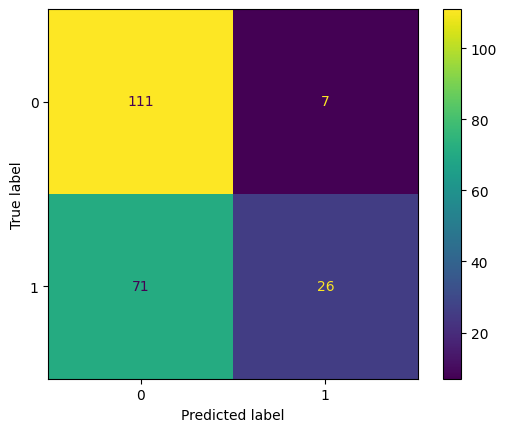

In [11]:
cm = confusion_matrix(y_test, pred_y, labels=[0, 1])
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Sigmoid function

We will first define the sigmoid function
$$
s(z)=\frac{1}{1+e^{-z}}
$$
in Python. Below is its graph.

In [12]:
def sigmoid(z):
    return 1. / (1. + np.exp(-z))

ref_data = pd.DataFrame({'x': np.arange(-5.0, 5.0, 0.1)})
ref_data['y'] = sigmoid(ref_data['x'])
px.line(ref_data, x = 'x', y = 'y')

Now we will define the sigmoid activation function, i.e., the prediction of logistic regression. Its output is
$$
p(x)=s\left(
\begin{bmatrix}
1 & x_1 & x_2
\end{bmatrix}\cdot
\begin{bmatrix}
\beta_0 \\ \beta_1 \\ \beta_2
\end{bmatrix}
\right)
$$

Below we use it to estimate the probability to survive the Titanic distaster for a hypothetical 10 year old passenger who paid 16 dollars for a ticket:

In [13]:
def sigmoid_activation(x, beta):
    # x can be a matrix or a vector
    if (len(x.shape) == 1):
        # This will be run if x is a vector
        # Needed so that it works correctly regardless of the input's shape
        x = x.reshape(1, x.shape[0])

    X = np.concatenate((np.ones((x.shape[0], 1)), x), axis = 1)
    W = np.array(beta).reshape(len(beta), 1)
    z = np.dot(X, W)
    return sigmoid(z)

print("Predicted probability for 10 years old with 16 dollars ticket:")
print(sigmoid_activation(np.array([10, 16]), beta_opt))

Predicted probability for 10 years old with 16 dollars ticket:
[[0.37752075]]


## The loss function

The loss of logistic regression is given by
$$
J(\beta)=-\sum_{i=1}^{N}y^{i}\log p(x^{i})
-\sum_{i=1}^{N}(1-y^{i})\log(1- p(x^{i}))
$$

Below we input it into Python

In [14]:
def J(beta, X = x_train, Y = y_train):
    predicted_y = sigmoid_activation(X, beta)
    return float(- np.sum(Y * np.log(predicted_y)) - np.sum((1-Y) * np.log(1 - predicted_y)))

print("Train loss for beta =", np.array(beta_opt), "is", J(beta_opt))
some_beta = np.array([-2, -0.2, -0.2])
print("Train loss for beta =", some_beta, "is", J(some_beta))


Train loss for beta = [-0.66462569 -0.01249362  0.01809232] is 306.8114664373922
Train loss for beta = [-2.  -0.2 -0.2] is 3581.77074030049


## Gradient of the loss function

The derivatives of the loss function are
$$
J_{\beta_0}=
\sum_{i=1}^{N}\left(p(x^{i})-y^{i}\right),\quad
J_{\beta_1}=
\sum_{i=1}^{N}\left(p(x^{i})-y^{i}\right)x^{i}_1,\quad
J_{\beta_2}=
\sum_{i=1}^{N}\left(p(x^{i})-y^{i}\right)x^{i}_2
$$

Below we input these functions into Python.

We report $\nabla J$ for two values of $\beta$ - the first of them is the outcome of the fitted logistic regression. It should be approximately $(0,0,0)$ since that's how the logistic regression is trained. The second value is reported for some arbitrarily chosen $\beta$.

In [15]:
def grad_J(beta, X = x_train, Y = y_train):
    # This function specifically designed for datasets with 2 features
    # It's not hard to change it to datasets with p features
    # But we will not do it since that's not our main objective now
    pred_actual = sigmoid_activation(X, beta) - Y
    N = X.shape[0]
    J0 = np.sum(pred_actual)
    J1 = float(np.dot(X[:, 0].reshape(1, N), pred_actual))
    J2 = float(np.dot(X[:, 1].reshape(1, N), pred_actual))
    return np.array([J0, J1, J2])

print("grad(J)(", beta_opt, ") = ", grad_J(beta_opt))
print("grad(J)(", some_beta, ") = ", grad_J(some_beta))


grad(J)( [-0.66462569 -0.01249362  0.01809232] ) =  [-4.44089210e-15 -1.13686838e-13 -3.19744231e-13]
grad(J)( [-2.  -0.2 -0.2] ) =  [  -192.86907149  -5705.60634972 -10269.77370736]


<ipython-input-15-f23b4e13d284>:8: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

<ipython-input-15-f23b4e13d284>:9: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



## Gradient descent implemented from scratch

Begin at some initial point and then update $\beta$ as follows
$$
\beta_{new}=\beta_{old}-
\alpha J_{\beta}
$$
This is what it looks like:

In [16]:
alpha = 1e-6
print("Learning rate =", alpha)

def grad_descent(num_steps, learning_rate, initial_beta = np.array([-2, -0.2, -0.2]),\
                         loss_function = J, grad_function = grad_J):
    p = len(initial_beta)-1 # in our case, p=2
    # but this function should work for other values of p as well
    # if we correctly define loss_function and grad_function

    result = np.zeros((num_steps + 1, p+1)) # Here we will store the trajectory of the gradient descent
    current_beta = np.copy(initial_beta)
    result[0, :] = current_beta
    for i in range(num_steps):
        current_beta = current_beta - learning_rate * grad_function(current_beta)
        result[i+1, :] = current_beta

    return(result)

G = grad_descent(10, alpha)
print("Below are consecutive iterations of the gradient descent:")
print(G)

Learning rate = 1e-06
Below are consecutive iterations of the gradient descent:
[[-2.         -0.2        -0.2       ]
 [-1.99980713 -0.19429439 -0.18973023]
 [-1.99961429 -0.18858911 -0.17946073]
 [-1.99942147 -0.18288422 -0.16919156]
 [-1.99922869 -0.17717982 -0.15892282]
 [-1.99903596 -0.17147603 -0.14865461]
 [-1.99884327 -0.16577299 -0.13838705]
 [-1.99865066 -0.16007088 -0.12812034]
 [-1.99845812 -0.15436994 -0.11785469]
 [-1.99826569 -0.14867046 -0.10759041]
 [-1.99807339 -0.14297282 -0.09732791]]


<ipython-input-15-f23b4e13d284>:8: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

<ipython-input-15-f23b4e13d284>:9: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



Values of the loss function should be decreasing at consecutive iterations of gradient descent.

In [17]:
print("Values of the loss function on the iteractions of gradient descent:")
print(np.apply_along_axis(J, 1, G))


Values of the loss function on the iteractions of gradient descent:
[3581.7707403  3443.71359091 3305.66626851 3167.63109053 3029.61098496
 2891.60967087 2753.6318991  2615.6837759  2477.77320203 2339.91047423
 2202.10911819]


Now we will generate a new tragectory of gradient descent with 1000 iterations and plot it

In [18]:
G6 = grad_descent(1000, 1e-6)
beta6 = G6[-1, :]
print("Final beta =", beta6)
df_gd = pd.DataFrame(G6, columns = ['const', 'Age', 'Fare'])
px.line(df_gd, x = 'Age', y = 'Fare')

Final beta = [-1.97041544  0.01812454  0.0229921 ]


<ipython-input-15-f23b4e13d284>:8: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

<ipython-input-15-f23b4e13d284>:9: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



### Exercise 3

Try to increase the learning rate 10 and 100 times as compared to our default $10^{-6}$. Explain what you see

In [19]:
G5 = grad_descent(1000, 1e-5)
beta5 = G5[-1, :]
print("Final beta =", beta5)
df_gd = pd.DataFrame(G5, columns = ['const', 'Age', 'Fare'])
px.line(df_gd, x = 'Age', y = 'Fare')

<ipython-input-15-f23b4e13d284>:8: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

<ipython-input-15-f23b4e13d284>:9: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



Final beta = [-1.79741327  0.01999568  0.04218748]


In [20]:
G4 = grad_descent(1000, 1e-4)
beta4 = G4[-1, :]
print("Final beta =", beta4)
df_gd = pd.DataFrame(G4, columns = ['const', 'Age', 'Fare'])
px.line(df_gd, x = 'Age', y = 'Fare')

Final beta = [-2.50689999 -0.72254573  0.00962994]


<ipython-input-15-f23b4e13d284>:8: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

<ipython-input-15-f23b4e13d284>:9: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



### Exercise 4

Find test accuracies of our home-made logistic models trained by gradient descent implemented from scratch (include models trained by 1000 steps of gradient descent with the learning rates $10^{-6}$, $10^{-5}$, and $10^{-4}$ respectively). Compare them to the model trained by the built-it Python function. Report results as a table.

You should see that the most accuracy of our home-made logistic models is the one with the learning rate $10^{-5}$. What conclustion can you make out of it?

In [21]:
# prompt: based on the instruction in above cell, generate the code to complete the task based on the context of this notebook

# Exercise 4
pred_probs_6 = sigmoid_activation(x_test, beta6)
pred_y_6 = 0. + (pred_probs_6 > 0.5)
gd_model_test_acc_6 = np.sum(pred_y_6.reshape(y_test.shape) == y_test) / len(y_test)

pred_probs_5 = sigmoid_activation(x_test, beta5)
pred_y_5 = 0. + (pred_probs_5 > 0.5)
gd_model_test_acc_5 = np.sum(pred_y_5.reshape(y_test.shape) == y_test) / len(y_test)

pred_probs_4 = sigmoid_activation(x_test, beta4)
pred_y_4 = 0. + (pred_probs_4 > 0.5)
gd_model_test_acc_4 = np.sum(pred_y_4.reshape(y_test.shape) == y_test) / len(y_test)

# Create a DataFrame for results
results = pd.DataFrame({
    'Model': ['Built-in Logistic Model', 'GD (1e-6)', 'GD (1e-5)', 'GD (1e-4)'],
    'Test Accuracy': [main_model_test_acc, gd_model_test_acc_6, gd_model_test_acc_5, gd_model_test_acc_4]
})

results

,Model,Test Accuracy
0,Built-in Logistic Model,0.637209
1,GD (1e-6),0.609302
2,GD (1e-5),0.632558
3,GD (1e-4),0.548837


# Theoretical problems

Here are some theoretical problems about artificial neural networks.

## Question 1

We have an artificial neural network
with one input layer,
two hidden layers, and a 1-dimensional output layer.
The activation function in both hidden layers
is the linear rectifier and in the output layer
sigmoid. The number of predictors is $p=2$.

(a) Are we doing regression, binary classification, or multiclass classification?

(b) We have written down weights and biases for layers 2 and 3 (hidden layers), but our notes are messy and we are not sure which is which. Among the following four matrices, figure out
which one represents biases in layer 2, which one represents biases in layer 3, which one represents weights in layer 2 and
which one represents weights in layer 3:
$$
\begin{bmatrix}
1 & 2 & 0 \\
0 & -4 & 2 \\
-1 & 1 & 1 \\
0 & 0 & 1
\end{bmatrix},
\begin{bmatrix}
-1 & 0 \\
4 & 2 \\
0 & -3
\end{bmatrix},
\begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix}
,
\begin{bmatrix}
-1 \\
0 \\
0 \\
1
\end{bmatrix}
$$

(c) Find the number of units in each layer.

(d) Given that the bias in layer 4 (output layer) is $-2$ and all the weights in layer 4 are equal to $1$, compute the prediction for the input $X_1=1$, $X_2=-1$.

### Solution

(a) binary classificaiton since sigmoid is used

(b) \begin{bmatrix}
-1 & 0 \\
4 & 2 \\
0 & -3
\end{bmatrix},
\begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix}
<br> Layer1 W and b
<br>
\begin{bmatrix}
1 & 2 & 0 \\
0 & -4 & 2 \\
-1 & 1 & 1 \\
0 & 0 & 1
\end{bmatrix},
\begin{bmatrix}
-1 \\
0 \\
0 \\
1
\end{bmatrix}
<br>
Layer2 W and b

(c) 3 and 4

(d) see cell below


In [22]:
# Define the ReLU activation function
def relu(x):
    return np.maximum(0, x)

# Define the sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Inputs for Layer 1
x = np.array([1, -1]).reshape(-1, 1)  # Reshape to column vector

# Layer 2 parameters (weights and bias)
W1 = np.array([[-1, 0],
               [4, 2],
               [0, -3]])  # Transpose to align dimensions
b1 = np.array([0, 0, 0]).reshape(-1, 1)  # Reshape bias to match output shape

# Forward pass through Layer 2
z1 = np.dot(W1, x) + b1
a2 = relu(z1)  # ReLU activation

# Layer 3 parameters (weights and bias)
W2 = np.array([[1, 2, 0],
               [0, -4, 2],
               [-1, 1, 1],
               [0, 0, 1]])  # Transpose to align dimensions
b2 = np.array([-1, 0, 0, 1]).reshape(-1, 1)  # Reshape bias to match output shape

# Forward pass through Layer 3
z2 = np.dot(W2, a2) + b2
a3 = relu(z2)  # ReLU activation

# Layer 4 parameters (weights and bias)
W3 = np.array([[1, 1, 1,1]])  # Transpose to align dimensions
b3 = np.array([-2.0]).reshape(-1, 1)  # Reshape bias to match output shape

# Forward pass through Layer 3
z3 = np.dot(W3, a3) + b3
output = sigmoid(z3)  # Sigmoid activation for the final output

# Print the final prediction output
print("Final prediction output:", output)

Final prediction output: [[0.9999546]]


## Question 2

We are given a fully connected feedforward
artificial neural network with $L$ layers
and weights and biases
$$
b^{(1)}, W^{(1)},
b^{(2)}, W^{(2)},\cdots,
b^{(L-1)}, W^{(L-1)}
$$
Activation functions in hidden layers are all
linear rectifiers and the activation function
in the output layer is softmax.

(a) If we rescale $X_i$, i.e., replace
all training observations $x_i^j$ with $k\times x_i^j$, where
$k$ is some constant, how should we adjust weights and biases
so that the new model yields the same predictions?

(b) If we translate $X_i$, i.e., replace
all training observations $x_i^j$ with $x_i^j+t$, where
$t$ is some constant, how should we adjust weights and biases
so that the new model yields the same predictions?

(c) If we replace $X_1$ with $X_1+X_2$, how should we adjust weights and biases so that the new model yields the same predictions?

### Solution

(a) W/k b remain the same (all changes only happen at layer 1 first hidden layer)

(b) W remains the same b-Wt (all changes only happen at layer 1 first hidden layer)

(c) W remains the same. b-W_1X_2


## Question 3

Here, we have two predictors, i.e., $p=2$, and a
binary response variable $Y\in\{0,1\}$.
Suppose that all training observations satisfy
$|x_1^i|>\varepsilon$ and $|x_2^i|>\varepsilon$ for some $\varepsilon>0$.
Construct an artificial neural network that predicts $1$
for a training observation whenever both $x_1^i>0$ and $x_2^i>0$ and predicts $0$ if $x_1^i<0$ or $x_2^i<0$. Your model should have one hidden layer with relu activation and an output layer with sigmoid activation.
<br> INTERESTING!!!

### Solution



# Fedor's answers

https://colab.research.google.com/drive/1yJh0888g4XNfQyDwjW778nlS086Yhysa?usp=sharing